# Chapter 3: Statistical Experiments and Significance Testing

This notebook reproduces the Python code from Chapter 3 of *Practical Statistics for Data Scientists* (2nd Edition) by Peter Bruce, Andrew Bruce, and Peter Gedeck.

The chapter covers the design of experiments and how to judge whether an observed effect is real or just due to chance. Topics include A/B testing, hypothesis tests, resampling and permutation tests, statistical significance and p-values, t-tests, multiple testing, degrees of freedom, ANOVA, the chi-square test, multi-arm bandit algorithms, and power and sample size.

In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt

DATA = Path('data')

## 1. A/B Testing

An **A/B test** is an experiment with two groups to determine which of two treatments, products, or procedures is better. Often one of the treatments is the standard (the **control**) and the other is the new one.

Key terms:
- **Treatment**: something (a drug, a price, a web headline) to which a subject is exposed.
- **Treatment group** and **control group**: the subjects exposed to the new treatment and to the standard (or no) treatment.
- **Randomization**: randomly assigning subjects to treatments, so that any difference between groups is due either to the treatment or to chance.
- **Test statistic**: the metric used to measure the effect of the treatment (e.g., difference in means or proportions).

A proper A/B test uses a control group and **blinding** where possible, and the test statistic should be decided **before** the experiment to avoid researcher bias.

The example compares the session time (in seconds) for visitors to two versions of a web page.

In [2]:
session_times = pd.read_csv(DATA / 'web_page_data.csv')
session_times['Time'] = 100 * session_times['Time']
session_times.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


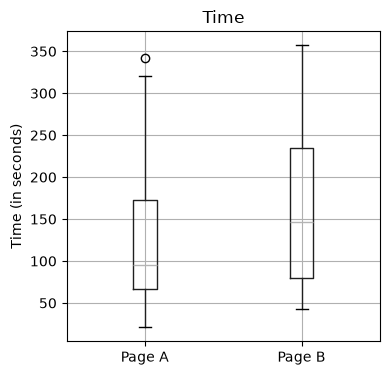

In [3]:
ax = session_times.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [4]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print('Mean difference (B - A):', mean_b - mean_a)

Mean difference (B - A): 35.66666666666667


Page B has a longer average session time than Page A. The question is whether this difference is real or could have happened by chance. The following sections answer that question.

## 2. Hypothesis Tests

A **hypothesis test** (significance test) helps determine whether random chance might be responsible for an observed effect.

- **Null hypothesis (H0)**: the hypothesis that chance is to blame, i.e., there is no real difference between the groups.
- **Alternative hypothesis (H1)**: the counterpart to the null, what we hope to show.
- **One-way (one-tailed) test**: counts chance results only in one direction (e.g., "B is better than A").
- **Two-way (two-tailed) test**: counts chance results in both directions (e.g., "A is different from B").

Humans tend to underestimate how much randomness can produce patterns that look meaningful. A hypothesis test protects against being fooled by chance: we assume the null hypothesis is true and check whether the observed result would be unusual under that assumption.

## 3. Resampling and the Permutation Test

**Resampling** means repeatedly sampling values from the observed data to assess random variability in a statistic. There are two main types: the **bootstrap** (covered in Chapter 2) and **permutation tests**.

In a **permutation test**:
1. Combine the results from all groups into a single dataset.
2. Shuffle the combined data, then randomly draw (without replacement) a resample of the same size as group A, and assign the rest to group B.
3. Calculate the test statistic for the resampled groups and record it.
4. Repeat steps 2 and 3 many times (e.g., 1,000 times) to build the permutation distribution.
5. If the observed difference lies well outside most of the permutation distribution, chance is probably not responsible, and the result is **statistically significant**.

Variants include the **exhaustive permutation test** (all possible splits are tried, practical only for small samples) and the **bootstrap permutation test** (draws are made with replacement).

Permutation tests are flexible: they make no assumption that the data is normally distributed and work for any test statistic.

In [5]:
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print('One permutation:', perm_fun(session_times.Time, nA, nB))

One permutation: -10.047619047619037


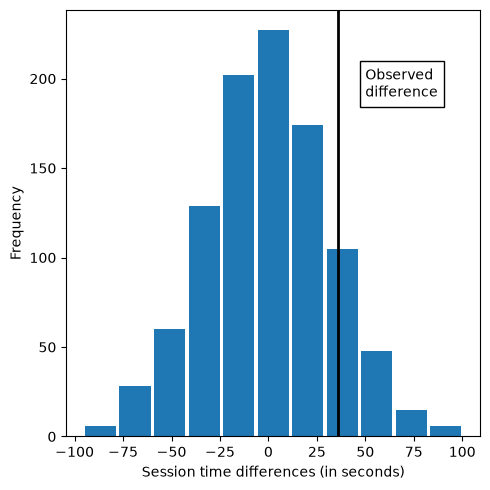

In [6]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor': 'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [7]:
print('Proportion of permutations exceeding observed difference:',
      np.mean(np.array(perm_diffs) > mean_b - mean_a))

Proportion of permutations exceeding observed difference: 0.121


A sizable fraction of the random permutations produce a difference as large as or larger than the observed one. This means the observed difference in session time is well within the range of chance variation, so it is **not** statistically significant.

## 4. Statistical Significance and p-Values

**Statistical significance** is how we measure whether an experiment produces a more extreme result than chance alone would.

- **p-value**: given a chance model that embodies the null hypothesis, the probability of obtaining results as unusual or extreme as the observed results.
- **Alpha (α)**: the probability threshold of "unusualness" that chance results must surpass for an outcome to be considered significant. Common values are 0.05 and 0.01.
- **Type 1 error**: wrongly concluding an effect is real when it is due to chance (false positive).
- **Type 2 error**: wrongly concluding an effect is due to chance when it is real (false negative).

Important caution: a p-value is **not** the probability that the result is due to chance, and it does not measure the size or importance of an effect. The American Statistical Association has warned against relying on p-values alone, and against treating "p < 0.05" as a magic threshold. Statistical significance does not automatically mean practical significance.

The example below uses an e-commerce experiment comparing two prices: Price A had 200 conversions out of 23,739 visitors, while Price B had 182 conversions out of 22,588 visitors.

Observed difference: 0.0368%


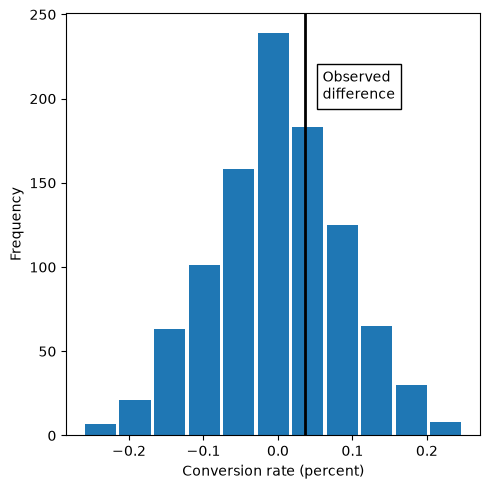

In [8]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')

conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor': 'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [9]:
print('Permutation p-value:', np.mean([diff > obs_pct_diff for diff in perm_diffs]))

Permutation p-value: 0.332


In [10]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test (normal approximation): {p_value / 2:.4f}')

p-value for single sided test (normal approximation): 0.3498


Both the permutation test and the normal approximation give a p-value well above 0.05. So the difference in conversion rates between the two prices is within the range of chance variation, and we cannot conclude that Price A is really better.

## 5. t-Tests

Before computers made resampling easy, statisticians used formula-based tests built on known distributions. The **t-test** is the most common of these and is based on the **Student's t-distribution** (introduced in Chapter 2).

- **Test statistic**: a metric for the difference or effect of interest.
- **t-statistic**: a standardized version of a common test statistic such as the difference in means.

The t-test approximates the permutation distribution with a mathematical formula. It assumes the data is roughly normal or the sample is reasonably large. Setting `equal_var=False` uses **Welch's t-test**, which does not assume the two groups have the same variance.

Below, the t-test is applied to the web page session time data from Section 1.

In [11]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [12]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


The t-test gives a p-value similar to the permutation test, confirming that the difference in session times between Page A and Page B is not statistically significant.

## 6. Multiple Testing

The more tests you run, the more likely you are to find a "significant" result purely by chance. For example, if you run 20 independent tests at α = 0.05, the probability of at least one false positive is about 64%.

- **Type 1 error inflation**: the more comparisons, the higher the chance of a false positive.
- **False discovery rate (FDR)**: across multiple tests, the rate of making a Type 1 error.
- **Alpha inflation**: the phenomenon where α (the false positive rate) increases as more tests are conducted.
- **Adjustment of p-values**: corrections such as the **Bonferroni adjustment** (divide α by the number of tests) make the threshold stricter.
- **Overfitting**: fitting the noise in the data.

This problem also applies to data science in general: trying many models, variables, or questions on the same data increases the risk of finding patterns that do not generalize. Using holdout data and keeping track of how many tests were run helps reduce this risk.

## 7. Degrees of Freedom

**Degrees of freedom (d.f.)** is the number of values in a calculation that are free to vary. For example, if you know the mean of 10 values, only 9 of them are free to vary; the 10th is determined by the others. This is why the sample variance divides by n - 1.

Degrees of freedom appear in the calculation of test statistics (t, F, chi-square) and determine the exact shape of their reference distributions.

In data science, degrees of freedom matter in regression with categorical variables: when creating dummy variables, one category must be left out (n - 1 dummies), otherwise the model has redundant predictors (**multicollinearity**). This is covered in Chapter 4.

## 8. ANOVA

When comparing more than two groups, we use **ANOVA (analysis of variance)**. Instead of testing every pair of groups (which leads to multiple testing problems), ANOVA asks one overall question: could all the groups share the same underlying mean, with the observed differences due to chance?

- **Pairwise comparison**: a hypothesis test between two groups among multiple groups.
- **Omnibus test**: a single test of the overall variance among multiple group means.
- **Decomposition of variance**: separating the total variability into variability between groups and within groups.
- **F-statistic**: the ratio of the variance between group means to the variance within groups. A large F means the group means differ more than expected by chance.
- **SS (sum of squares)**: deviations from some average value.

ANOVA can be done with a permutation test or with the formula-based F-test.

The example uses session times on four different web pages.

In [13]:
four_sessions = pd.read_csv(DATA / 'four_sessions.csv')
four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


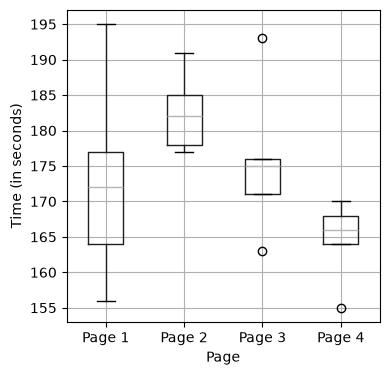

In [14]:
ax = four_sessions.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')
plt.tight_layout()
plt.show()

In [15]:
observed_variance = four_sessions.groupby('Page')['Time'].mean().var()
print('Observed means:', four_sessions.groupby('Page')['Time'].mean().values)
print('Variance:', observed_variance)

def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page')['Time'].mean().var()

print('One permutation:', perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
One permutation: 4.226666666666666


Pr(Prob): 0.08433333333333333


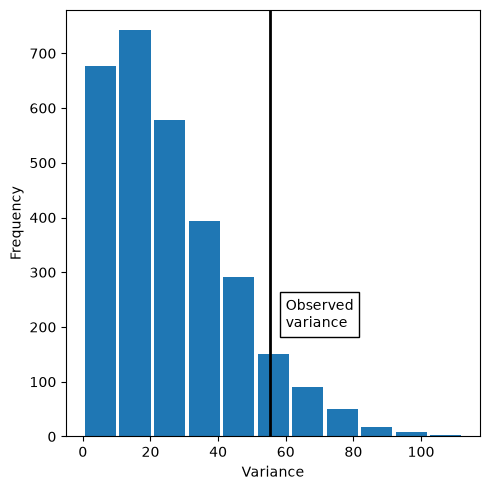

In [16]:
np.random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob):', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor': 'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

The permutation p-value shows how often random shuffling produces a variance among page means as large as the one observed. The F-statistic approach below gives a formula-based version of the same test.

In [17]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


In [18]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time,
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic:.4f}')
print(f'p-value: {res.pvalue:.4f}')

F-Statistic: 2.7398
p-value: 0.0776


The ANOVA table and `f_oneway` give the same F-statistic and p-value. The p-value is close to the result from the permutation test, which shows that the two approaches lead to a similar conclusion.

## 9. Chi-Square Test

The **chi-square test** is used with count data to test how well it fits some expected distribution. In statistics, it is most commonly used with r × c contingency tables to test whether the variables are independent.

- **Chi-square statistic**: a measure of how far observed counts are from the expected counts under the null hypothesis.
- **Expectation (expected counts)**: how we would expect the data to turn out under the null hypothesis, usually that the proportions are the same across groups.
- **Pearson residual**: (observed - expected) / √expected. The chi-square statistic is the sum of squared Pearson residuals.

The test can be done with resampling or with the formula-based chi-square distribution. When counts are very small, **Fisher's exact test** is a better choice because it computes all possible permutations exactly.

The example compares click-through rates for three web headlines, each shown 1,000 times.

In [19]:
click_rate = pd.read_csv(DATA / 'click_rates.csv')
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
clicks

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


In [20]:
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


The table above shows the expected counts under the null hypothesis that all three headlines have the same click rate. Next, a resampling (permutation) chi-square test is done by putting all 34 clicks and 2,966 non-clicks into one "box" and randomly drawing three groups of 1,000.

In [21]:
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect for observe in row])
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun_chi2(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun_chi2(box) for _ in range(2000)]

resampled_p_value = np.mean(np.array(perm_chi2) > chi2observed)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4820


In [22]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


Both the resampling test and the formula-based test give a p-value above 0.05, so the differences in click rates among the three headlines could be due to chance.

### Relevance for data science: detecting fraud

The chi-square idea can also be used to check whether data looks "too regular" or "too random". In the example below from Imanishi-Kari's research data, the frequency of each interior digit should be roughly uniform. Significant deviations from uniformity were used as evidence that some data may have been fabricated.

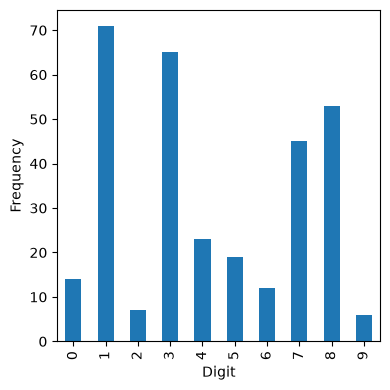

In [23]:
imanishi = pd.read_csv(DATA / 'imanishi_data.csv')
imanishi.columns = [c.strip() for c in imanishi.columns]

ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False, figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 10. Multi-Arm Bandit Algorithm

**Multi-arm bandits** offer an alternative to traditional A/B tests, especially for web optimization. The name comes from a slot machine with multiple arms, each paying out at a different rate.

- **Arm**: a treatment in an experiment (e.g., a headline in a web test).
- **Win**: the experimental analog of a win at the slot machine (e.g., a customer clicks).
- **Exploration vs exploitation**: the trade-off between trying different arms to learn which is best (explore) and using the arm that currently looks best (exploit).

Unlike a classical A/B test, where traffic is split evenly until the end, a bandit algorithm shifts more traffic to the better-performing arm during the experiment. This reduces the cost of showing an inferior option.

Common algorithms:
- **Epsilon-greedy**: with probability ε, choose a random arm (explore); otherwise choose the best arm so far (exploit).
- **Thompson sampling**: uses a Bayesian approach, sampling from the posterior distribution of each arm's payoff to decide which arm to play next.

## 11. Power and Sample Size

Before running an experiment, it is important to decide how large the sample needs to be.

- **Effect size**: the minimum size of the effect you hope to detect (e.g., a 20% improvement in click rate).
- **Power**: the probability of detecting a given effect size with a given sample size.
- **Significance level**: the α level at which the test will be conducted.

These four quantities (sample size, effect size, significance level, and power) are related: if you specify any three, you can calculate the fourth. Most commonly, we want to calculate the required sample size. Detecting a smaller effect requires a larger sample.

Example: the current click rate is 1.1%, and we want to detect an increase to 1.21% (a 10% improvement), with α = 0.05 and power = 0.8.

In [ ]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05,
                              power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Now consider a larger effect: detecting an increase from 1.1% to 1.65% (a 50% improvement).

In [ ]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05,
                              power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Detecting a 10% improvement requires a very large sample per group, while detecting a 50% improvement requires a much smaller one. This shows how strongly the required sample size depends on the effect size we want to detect.

## Summary

This chapter explains how to design experiments and how to tell whether an observed result is real or just due to chance.

Key takeaways:
- A/B tests compare two treatments using randomization and a control group. The test statistic should be decided before the experiment.
- Hypothesis tests assume the null hypothesis (no real effect) and check whether the observed result would be unusual under that assumption.
- Permutation tests are a flexible, assumption-light resampling approach for testing differences between groups.
- p-values measure how unusual a result is under the null hypothesis, but they do not measure the size or importance of an effect and should not be treated as a strict cutoff.
- t-tests are formula-based alternatives to permutation tests for comparing two means.
- Running many tests increases the chance of false positives, so corrections and holdout data are important.
- Degrees of freedom affect the shape of test distributions and matter when creating dummy variables in regression.
- ANOVA and the F-statistic compare means across more than two groups, and the chi-square test compares counts across categories.
- Multi-arm bandits balance exploration and exploitation, and can be more efficient than classical A/B tests for web optimization.
- Power analysis determines the sample size needed to detect a given effect size.